# Square-wave actuation: 2-day decell tissue (2026-06-15)

Time-aligned panels for the 1500 s square-wave step experiment:

1. **Force (raw)** - scope force-sensor log (CH2) in mN / stress in MPa, with the
   linear **creep fit** drawn through the force at t = 3000 s and t = 6000 s.
2. **Force (creep-corrected)** - same trace with that linear drift removed
   (from 1500 s onward; the t < 1500 s settling region is skewed and dropped).
3. **Current** - potentiostat MultiStep Amperometry (uA).
4. **Applied potential** - +1 V for 1500 s, then -1 V for 1500 s, repeating.

t = 3000 s and t = 6000 s are both -1 V -> +1 V reversals (same point in the cycle),
so absent creep the force there should be equal. We fit a straight line between them
and subtract it, which forces those two points to coincide.

Red dashed vertical lines mark every reversal (1500, 3000, 4500, 6000 s) and bisect
all panels. Scope and potentiostat were started together (offset = 0 s).

**Geometry / calibration** (same specimen as `cv_20260615_FORCE_analysis.ipynb`):
Force = scope-V x 56.7 mN/V; A = 2.5 mm x 0.45 mm = 1.125 mm^2; 1 mN/mm^2 = 1e-3 MPa.

In [1]:
import io, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

SCOPE_CSV = 'scope_log_20260615_151214_2day_decell_tissue_1500sec_square_wave_potential_1v_then_neg1V.csv'
POTEN_CSV = 'Potentiostat_measurements/06.15.26-2Day-formalin-decell_tissue-1500sec_square_wave.csv'

SCOPE_CHANNEL    = 'ch2_MEAN_V'   # force signal is on CH2 (CH1 is 0)
FORCE_GAIN_MN_PER_V = 56.7        # Aurora Force Out, 1x gain

# Specimen cross-section (same specimen as cv_20260615_FORCE_analysis.ipynb)
WIDTH_MM, THICKNESS_MM = 2.5, 0.45
AREA_MM2 = WIDTH_MM * THICKNESS_MM                 # 1.125 mm^2
def mN_to_MPa(f):  return f / (AREA_MM2 * 1000.0)  # 1 mN/mm^2 = 1 kPa = 1e-3 MPa
def MPa_to_mN(s):  return s * (AREA_MM2 * 1000.0)

HALF_PERIOD_S = 1500.0            # +1 V for 1500 s, then -1 V for 1500 s, ...
V_AMP         = 1.0
CREEP_T0, CREEP_T1 = 3000.0, 6000.0   # anchor reversals for the creep fit
CORRECT_FROM_S = 1500.0          # only show corrected force from here on

WINDOW, K = 41, 5.0                                  # MAD outlier filter
SMOOTH_WINDOW, SAVGOL_POLY, RAW_ALPHA = 101, 3, 0.25

In [2]:
# ---- 1. Potentiostat current (UTF-16, 6-line header; columns: s, uA) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('\ufeff', '')
rows = list(csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))))
rows = [r for r in rows if r and r[0]]
poten = pd.DataFrame([[float(r[0]), float(r[1])] for r in rows], columns=['t_s', 'i_uA'])
print(f'Potentiostat: {len(poten)} samples, t = {poten.t_s.min():.1f}..{poten.t_s.max():.1f} s')

# ---- 2. Scope force log (offset = 0; started with the potentiostat) ----
scope = pd.read_csv(SCOPE_CSV)
scope['t_s'] = scope['elapsed_s']

def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad = mad.clip(lower=max(np.nanstd(x) * 1e-3, 1e-9))
    return (abs_dev > k * mad).values

scope_clean = scope.loc[~mark_outliers(scope[SCOPE_CHANNEL].values, WINDOW, K)].copy()
scope_clean['force_mN'] = scope_clean[SCOPE_CHANNEL] * FORCE_GAIN_MN_PER_V

n = len(scope_clean)
win = min(SMOOTH_WINDOW, n if n % 2 else n - 1)
scope_clean['force_smooth'] = (savgol_filter(scope_clean['force_mN'].values, win, SAVGOL_POLY)
                               if n > SAVGOL_POLY else scope_clean['force_mN'].values)
print(f'Scope: {len(scope_clean)}/{len(scope)} samples kept')

# ---- 3. Linear creep fit anchored at the two -1 V -> +1 V reversals ----
t = scope_clean['t_s'].values
F0 = float(np.interp(CREEP_T0, t, scope_clean['force_smooth'].values))
F1 = float(np.interp(CREEP_T1, t, scope_clean['force_smooth'].values))
creep_slope = (F1 - F0) / (CREEP_T1 - CREEP_T0)            # mN/s
creep_line  = F0 + creep_slope * (t - CREEP_T0)            # the drawn fit
# remove the drift, anchored so t=3000 stays put (then t=6000 lands on the same value)
scope_clean['force_corr']        = scope_clean['force_mN']     - creep_slope * (t - CREEP_T0)
scope_clean['force_corr_smooth'] = scope_clean['force_smooth'] - creep_slope * (t - CREEP_T0)
print(f'Force @3000 s = {F0:.1f} mN, @6000 s = {F1:.1f} mN  ->  creep = {F1-F0:+.1f} mN '
      f'over {CREEP_T1-CREEP_T0:.0f} s ({creep_slope*1000:+.3f} mN/1000 s)')

# ---- 4. Applied-potential square wave + reversal times ----
t_end = max(scope.t_s.max(), poten.t_s.max())
reversals = np.arange(HALF_PERIOD_S, t_end, HALF_PERIOD_S)
def applied_V(tt):
    return np.where((np.floor(tt / HALF_PERIOD_S).astype(int) % 2) == 0, V_AMP, -V_AMP)
print('Potential reversals at (s):', reversals)

Potentiostat: 64270 samples, t = 0.0..6426.9 s
Scope: 12900/12996 samples kept
Force @3000 s = 211.0 mN, @6000 s = 235.4 mN  ->  creep = +24.4 mN over 3000 s (+8.146 mN/1000 s)
Potential reversals at (s): [1500. 3000. 4500. 6000.]


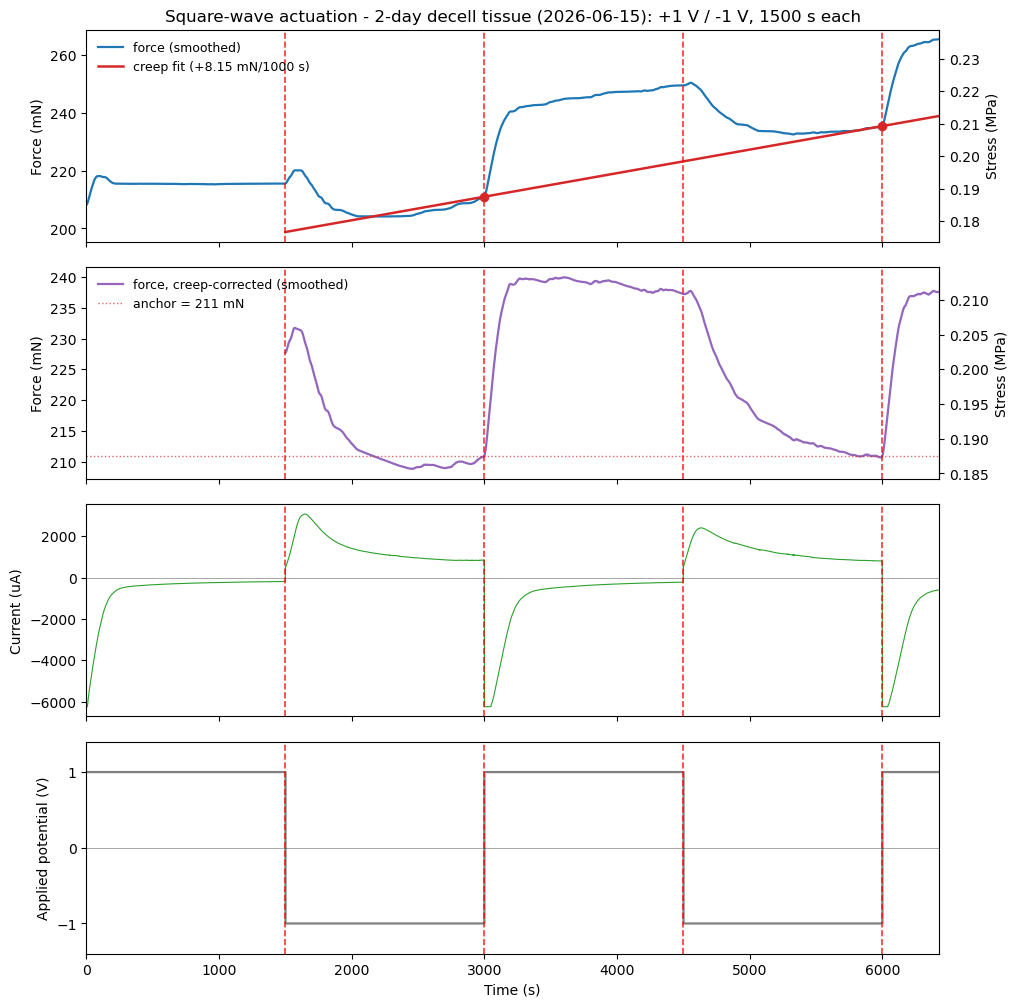

Saved square_wave_20260615_force_current_potential.png


In [3]:
# ---- Four time-aligned panels with shared red-dashed reversal lines ----
C_FORCE, C_CORR, C_CURR, C_POT, C_FIT = '#1f77b4', '#9467bd', '#2ca02c', '#7f7f7f', '#d62728'

def add_stress_axis(ax):
    axs = ax.secondary_yaxis('right', functions=(mN_to_MPa, MPa_to_mN))
    axs.set_ylabel('Stress (MPa)')
    return axs

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(11, 12), sharex=True,
                                         gridspec_kw={'hspace': 0.12})

# Panel 1: raw force + creep fit line
ax1.plot(t, scope_clean.force_mN, color=C_FORCE, lw=0.6, alpha=RAW_ALPHA)
ax1.plot(t, scope_clean.force_smooth, color=C_FORCE, lw=1.6, label='force (smoothed)')
fit_mask = t >= CORRECT_FROM_S
ax1.plot(t[fit_mask], creep_line[fit_mask], color=C_FIT, lw=1.8, ls='-',
         label=f'creep fit ({creep_slope*1000:+.2f} mN/1000 s)')
ax1.scatter([CREEP_T0, CREEP_T1], [F0, F1], color=C_FIT, zorder=5, s=35)
ax1.set_ylabel('Force (mN)')
ax1.legend(loc='upper left', fontsize=9, frameon=False)
add_stress_axis(ax1)

# Panel 2: creep-corrected force (from 1500 s onward)
cm = t >= CORRECT_FROM_S
ax2.plot(t[cm], scope_clean.force_corr.values[cm], color=C_CORR, lw=0.6, alpha=RAW_ALPHA)
ax2.plot(t[cm], scope_clean.force_corr_smooth.values[cm], color=C_CORR, lw=1.6,
         label='force, creep-corrected (smoothed)')
ax2.axhline(F0, color=C_FIT, ls=':', lw=1.0, alpha=0.7, label=f'anchor = {F0:.0f} mN')
ax2.set_ylabel('Force (mN)')
ax2.legend(loc='upper left', fontsize=9, frameon=False)
add_stress_axis(ax2)

# Panel 3: current
ax3.plot(poten.t_s, poten.i_uA, color=C_CURR, lw=0.8)
ax3.axhline(0, color='k', lw=0.6, alpha=0.4)
ax3.set_ylabel('Current (uA)')

# Panel 4: applied potential
t_grid = np.linspace(0, t_end, 4000)
ax4.plot(t_grid, applied_V(t_grid), color=C_POT, lw=1.6, drawstyle='steps-post')
ax4.axhline(0, color='k', lw=0.6, alpha=0.4)
ax4.set_ylabel('Applied potential (V)')
ax4.set_ylim(-1.4, 1.4); ax4.set_yticks([-1, 0, 1])
ax4.set_xlabel('Time (s)')
ax4.set_xlim(0, t_end)

for ax in (ax1, ax2, ax3, ax4):
    for x in reversals:
        ax.axvline(x, color='red', ls='--', lw=1.2, alpha=0.8)
    ax.margins(x=0)

ax1.set_title('Square-wave actuation - 2-day decell tissue (2026-06-15): '
              '+1 V / -1 V, 1500 s each', fontsize=12)
fig.savefig('square_wave_20260615_force_current_potential.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved square_wave_20260615_force_current_potential.png')